## Practical session 7: Projected gradient descent and alternating projection algorithms



In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Recalls on projection

Given a set $C \subset \mathbb{R}^d$, and $y \in \mathbb{R}^d$, we consider the set
$$
\textrm{argmin}_{x \in C} \frac{1}{2} \| x - y \|^2.
$$
When the above set is reduced to a singleton, we call this element the projection of $y$ on $C$, and denote it by $\textrm{proj}_C(y)$. The vector $\textrm{proj}_C(y)$ is the element of $C$ which is the closest to $y$. When $C$ is non-empty, closed, and convex, $\textrm{proj}_C(y)$ is well-defined for any $y \in \mathbb{R}^d$.

Computing the projection of $y \in \mathbb{R}^d$ on $C$ amounts to solve an optimization problem, whose solution may not admit an explicit formula. Some projections, however, are easy to compute. We recall three examples below.

When $C = \{ x \in \mathbb{R}^d \textrm{ s.t. } v^\top x \leq w\}$ (that is when $C$ is a half-space), we have the following: If $y \in C$, then $\textrm{proj}_C(y) = y$, else,
$$
\textrm{proj}_C(y) = y - \frac{v^\top y - w}{\|v\|^2} v.
$$

A variant of the above is when $C$ is a hyper-plane of $\mathbb{R}^d$, that is when $C = \{ x \in \mathbb{R}^d \textrm{ s.t. } v\top x = w\}$. In this case, for any $y \in \mathbb{R}^d$,
$$
\textrm{proj}_C(y) = y - \frac{v^\top y - w}{\|v\|^2} v.
$$

Another example is $C = \{x \in \mathbb{R}^d \textrm{ s.t. } \|x \| = 1\}$. This set is not convex, but it is closed and non-empty. It is possible to show that for any $y \in \mathbb{R}^d \setminus \{ 0 \}$, the projection of $y$ on $C$ is well-defined and that
$$
\textrm{proj}_C(y) = \frac{1}{\| y \|} y.
$$
At zero, the projection is ill-defined (constraint qualification fails).

### Projected gradient descent for constrained optimization problems

For some optimization problems, not every $x \in \mathbb{R}^d$ is a valid solution, and so we will aim at minimizing the objective function $f$ over a restricted set $C \subset \mathbb{R}^d$, meaning that we are looking at
$$
\min_{x \in C} f(x).
$$
Constrained optimization problem require more involved analysis and algorithms that unconstrained ones. For instance, if $x_*$ is a solution of the above problem, we may no longer have $\nabla f(x_*) = 0$ (this is only true if $x_* \in \textrm{int } C$). The choice of algorithm to solve a given problem must depend on $f$ and on $C$. 

If $C$ is such that $\textrm{proj}_C$ is easy to compute and $f$ is differentiable, then we can use the projected gradient descent algorithm. The algorithm is initialized with $x_0 \in \mathbb{R}^d$ ($x_0$ need not belong to $C$) and uses a step size $\tau > 0$. Then, the update at iteration $ k \in \mathbb{N}$ is defined by
$$
x_{k+1} = \textrm{proj}_C(x_k - \tau \nabla f(x_k)).
$$

> Complete the code of the function `proj_GD` in the file `algorithms.py` with a stopping criteria of the form $\| x_{k+1} - x_k\| \leq \epsilon$.

### A first toy example

Let us consider the minimization of a quadratic function on half-space in dimension two, implemented in the file `problem1.py`.

> Implement the projection onto a half-space (in the file `problem1.py`).

> Run the projected gradient descent algorithm on the problem described in `problem1.py`, starting from an random point of $[-5,5]^2$, with step size $\tau \in \{0.3, 0.54, 0.55\}$. Plot the level sets of the objective function and the trajectory of the iterates. Plot the evolution of the objective function value and the norms of the gradients. What do you observe?

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 13 iterations -- 0.000794s -- final value: 0.375000 -- final gradient norm: 0.749993 




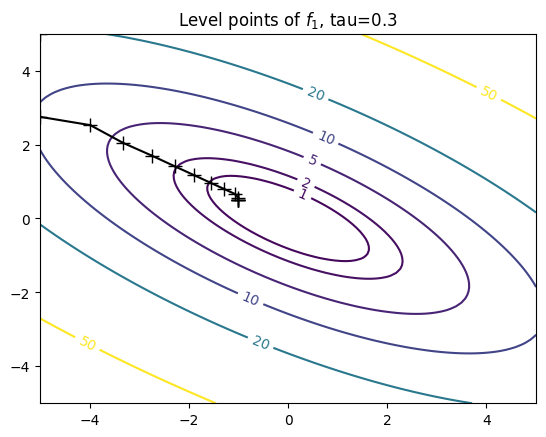

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 40 iterations -- 0.001136s -- final value: 0.375000 -- final gradient norm: 0.750027 




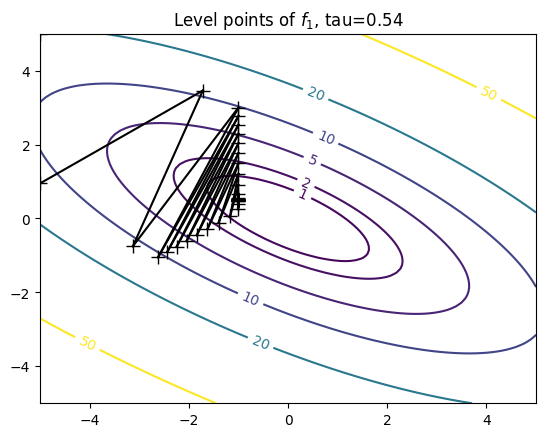

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 61 iterations -- 0.002004s -- final value: 0.375000 -- final gradient norm: 0.749959 




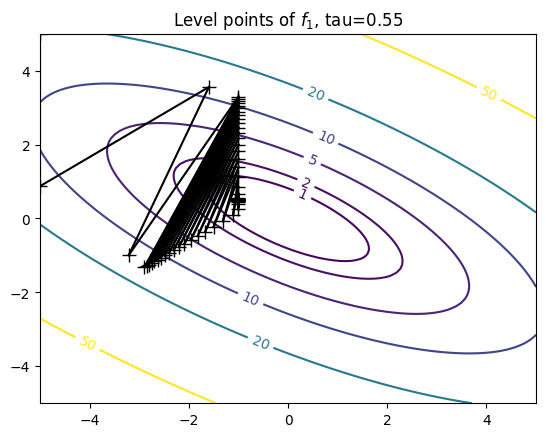

In [21]:
import problem1 as pb1
from algorithms import *
from utils import level_points_plot

x0 = (-5,5)
tau = 0.3
iterMax=5000
prec = 1e-5

x,x_tab = proj_GD(pb1.f, pb1.grad_f, pb1.proj, x0, tau, iterMax, prec)
level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,f"Level points of $f_1$, tau={tau}")
tau = 0.54
x,x_tab = proj_GD(pb1.f, pb1.grad_f, pb1.proj, x0, tau, iterMax, prec)
level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,f"Level points of $f_1$, tau={tau}")

tau = 0.55
x,x_tab = proj_GD(pb1.f, pb1.grad_f, pb1.proj, x0, tau, iterMax, prec)
level_points_plot(pb1.f,x_tab,pb1.lb,pb1.ub,pb1.nb_points,pb1.levels,f"Level points of $f_1$, tau={tau}")

### Computing the minimum eigenvalue as the resolution of an optimization problem

We now turn to a second constrained optimization problem, corresponding to the file `problem2.py`. Consider a symmetric matrix $A \in \mathbb{R}^{d \times d}$. Then, its minimum eigenvalue is the value of the optimization problem
$$
\min_{\| x \| = 1} x^\top A x.
$$
You will apply projected gradient descent to solve this problem.

> Implement the projection onto the sphere (in the file `problem2.py`).

> Run the projected gradient descent algorithm on this problem, starting from some random initialization, with step size $\tau = 10^{-3}$ and $10^5$ iterations. Plot the evolution of the objective value function and of the norm of the gradients.

------------------------------------
 GD with constant step size
------------------------------------
START
FINISHED -- 1765 iterations -- 0.021779s -- final value: -1.151340 -- final gradient norm: 2.305496 




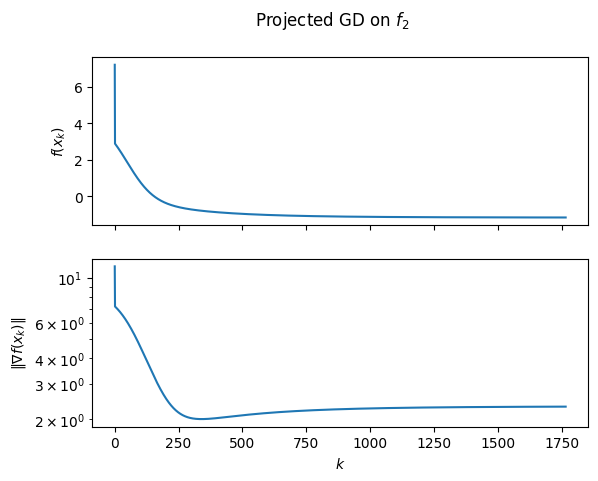

In [22]:
import problem2 as pb2
from utils import plot_obj_normGrad

x0 = np.random.rand(pb2.d)
tau = 1e-3
iterMax=100_000
prec = 1e-5

x,x_tab = proj_GD(pb2.f, pb2.grad_f, pb2.proj, x0, tau, iterMax, prec)

plot_obj_normGrad(x_tab, pb2.f, pb2.grad_f, title="Projected GD on $f_2$")

> Compare the value of $f(x_K)$, where $x_K$ is the final iterate you obtained by running projected gradient descent, with the minimal eigenvalue of $A$.

In [23]:
### TO BE COMPLETED
min_eig_val = np.linalg.eigvals(pb2.A).min()
print(min_eig_val)
print(pb2.f(x))

-1.1565664349492584
-1.1513401698249703


### Computing projection in more complicated situations

The projection does not always admit an explicit formula when the set $C$ is intricate. In this section, we consider the case when $C$ can be described as a intersection of $I$ sets: 
$$
C = \cap_{i=1}^I C_i.
$$
If for every $i \in \{1,\dots,I\}$, $\textrm{proj}_{C_i}$ is easy to compute, then, it is possible to generate a sequence $\{ x_k \}$ such that $\textrm{dist}(x, C) \rightarrow 0$, using the method of alternating projections. This algorithm, sometimes called projection onto convex sets (POCS), consists in applying all the projection operators in succession. Starting from $x_0 \in \mathbb{R}^d$, the algorithm's $k$-th update is given by
$$
x_{k+1} = \textrm{proj}_{C_I} \circ \dots \circ \textrm{proj}_{C_1} (x_k).
$$

### An application to find feasible trajectories

Consider the controlled discrete-time dynamical systems, whose dynamics is given at any $t \in \mathbb{N}$ by
$$
x_{t+1} = (1 + a)x_t - u_t,
$$
where $x_t$ is the state of the system at time $t$, and $u_t$ is the control applied to the system at time $t$. This system can model exploited biological systems with $x_k$ representing the stock of a renewable ressource growing at a linear rate and $u_k$ representing the catch. We may consider a trajectory $x \in \mathbb{R}^{T+1}$ and a control $u \in \mathbb{R}^T$ admissible if:
- $x_{t+1} = (1 + a)x_t - u_t$ for each $t \in \{0,\dots, T\}$ (the dynamics is satisfied),
- $x_t \geq \underline{x}$ for all $t \in \{0,\dots, T\}$ for some threshold $\underline{x} > 0$ (stock remains sufficiently high throughout the time period),
- $x_0 = x_T$ (stock returns to its initla state at the end of the time period),
- $u_t \geq 0$ at every $t \in \{0,\dots, T\}$ (the catch is always non-negative),
- $\sum_{t=0}^T \exp(-\alpha t) u_t \geq \underline{u}$ (the cumulated catch is above some threshold with more importance given to early catch).


Remark that each of the above point corresponds to $(x,u)$ belonging to half-space or a hyper-plane. Further, it is possible to remark that $u$ can be expressed as a function of $x$ through $u_t = (1+a)x_t - x_{t+1}$, allowing to reduce the dimension of the problem.

> Implement the individual projection operators $\textrm{proj}_{C_i}$, as well as their composition, in the file `problem3.py`, where constants $a, T, \underline{x}, \underline{u}, \alpha$ as well as some useful functions have already been implemented.

> Run the POCS algorithm already implemented in the file `algorithms.py` to find an admissible trajectory.

In [24]:
import problem3 as pb3
x_0 = np.random.rand(pb3.T + 1)
u_0 = pb3.u_from_x(x_0)

# POCS works on the concatenated variable z = (x, u)
z_init = np.concatenate((x_0, u_0))
z, z_tab = POCS(pb3.proj, z_init, iterMax=1000)

x = z[:pb3.T + 1]
u = z[pb3.T + 1:]

------------------------------------
 POCS 
------------------------------------
START
FINISHED -- 999 iterations -- 0.038169s 




> Check whether the constraints are satisfied by the trajectory returned by the algorithm by plotting $x$ and $u$ and computing the cumulated catch.

Max dynamics residual: 5.329e-15
x_t >= x_threshold (1.0): True
x_0 = x_T: True (gap = 0.000e+00)
u_t >= 0: True (min u = 1.090e-37)
Cumulated catch = 6.000000 >= 6.0: True


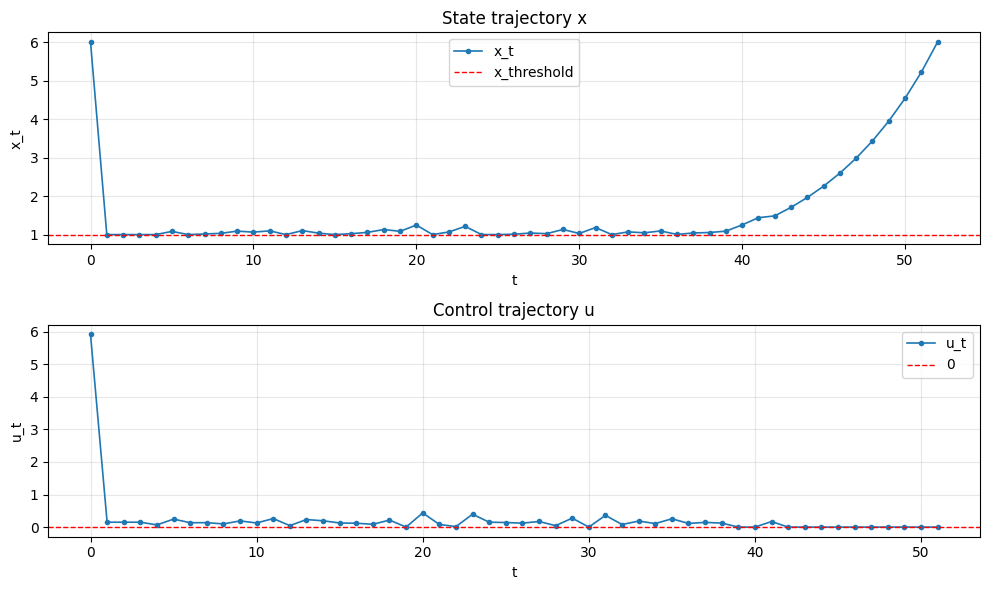

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Final trajectory produced by POCS
x_final = x
u_final = u

tol = 1e-8

# Constraint checks
dyn_residual = np.max(np.abs(x_final[1:] - ((1 + pb3.a) * x_final[:-1] - u_final)))
x_constraint_ok = np.all(x_final >= pb3.x_threshold - tol)
periodic_ok = np.abs(x_final[0] - x_final[-1]) <= tol
u_constraint_ok = np.all(u_final >= -tol)
cum_catch = pb3.cumulated_catch(u_final)
catch_ok = cum_catch >= pb3.u_threshold - tol

print(f"Max dynamics residual: {dyn_residual:.3e}")
print(f"x_t >= x_threshold ({pb3.x_threshold}): {x_constraint_ok}")
print(f"x_0 = x_T: {periodic_ok} (gap = {abs(x_final[0]-x_final[-1]):.3e})")
print(f"u_t >= 0: {u_constraint_ok} (min u = {u_final.min():.3e})")
print(f"Cumulated catch = {cum_catch:.6f} >= {pb3.u_threshold}: {catch_ok}")

# Plot x and u along time
t_x = np.arange(pb3.T + 1)
t_u = np.arange(pb3.T)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

axes[0].plot(t_x, x_final, marker="o", markersize=3, linewidth=1.2, label="x_t")
axes[0].axhline(pb3.x_threshold, color="r", linestyle="--", linewidth=1.0, label="x_threshold")
axes[0].set_title("State trajectory x")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x_t")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(t_u, u_final, marker="o", markersize=3, linewidth=1.2, label="u_t")
axes[1].axhline(0.0, color="r", linestyle="--", linewidth=1.0, label="0")
axes[1].set_title("Control trajectory u")
axes[1].set_xlabel("t")
axes[1].set_ylabel("u_t")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()